# Day 2: Model Validation

Trains and validates all Day 2 ML models:
1. **Isolation Forest** — anomaly detection on healthy baselines
2. **Piecewise Linear RUL** — knee detection + linear extrapolation
3. **Sensor Trend Analysis** — rolling stats, CUSUM change-points, cross-sensor divergence
4. **Health Index Composite** — weighted anomaly + RUL

Evaluation approach: since all units in FD001 training data run to failure,
we know ground-truth RUL at every cycle. We validate that:
- Anomaly scores increase as units approach failure
- RUL estimates correlate with true RUL
- Trend analysis detects degradation onset
- Health index tracks overall condition realistically

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.config import (
    KEY_SENSORS, INFORMATIVE_SENSORS, DATA_PROCESSED_DIR,
    EXPECTED_MEDIAN_LIFE, HEALTHY_FRACTION,
)
from src.models.anomaly_detector import train_isolation_forest, score_window
from src.models.rul_estimator import build_degradation_profiles, estimate_rul
from src.models.trend_analyzer import analyze_trends
from src.models.health_index import compute_health_index, health_label

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

df = pd.read_csv(DATA_PROCESSED_DIR / "train_FD001.csv")
print(f"Loaded {len(df)} rows, {df['unit_id'].nunique()} units")

Loaded 20631 rows, 100 units


## 1. Train Isolation Forest

In [2]:
train_meta = train_isolation_forest()
print(f"Trained on {train_meta['n_healthy_samples']} healthy samples")
print(f"Features ({train_meta['n_features']}): {train_meta['features']}")
print(f"Contamination: {train_meta['contamination']}")
print(f"Model saved to: {train_meta['model_path']}")

Trained on 6144 healthy samples
Features (14): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Contamination: 0.05
Model saved to: D:\Python\Turbofan_Degradation_Monitor\notebooks\..\models\saved\isolation_forest.joblib


### 1.1 Validate: Anomaly Scores vs Engine Life

Expectation: anomaly scores should increase (become more anomalous) as
units approach end-of-life.

In [3]:
# Score a sample of units at different life stages
sample_units = [1, 10, 25, 50, 75, 100]
window_size = 30

results = []
for unit_id in sample_units:
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    # Score at 25%, 50%, 75%, and 95% of life
    for pct in [0.25, 0.50, 0.75, 0.95]:
        cutoff = int(max_cycle * pct)
        window = unit_data[unit_data["cycle"] <= cutoff].tail(window_size)
        if len(window) < 10:
            continue
        result = score_window(window)
        results.append({
            "unit_id": unit_id,
            "pct_life": pct,
            "true_rul": max_cycle - cutoff,
            "anomaly_score": result["anomaly_score"],
            "normalized_score": result["normalized_score"],
            "is_anomalous": result["is_anomalous"],
            "pct_anomalous": result["pct_anomalous_readings"],
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 unit_id  pct_life  true_rul  anomaly_score  normalized_score  is_anomalous  pct_anomalous
       1      0.25       144       0.070310         87.869108         False       0.000000
       1      0.50        96       0.069839         87.726269         False       0.000000
       1      0.75        48       0.034572         77.030694         False       0.066667
       1      0.95        10      -0.127303         27.937362          True       1.000000
      10      0.25       167       0.045497         80.343940         False       0.033333
      10      0.50       111       0.073448         88.820975         False       0.000000
      10      0.75        56       0.041137         79.021732         False       0.133333
      10      0.95        12      -0.127875         27.763910          True       1.000000
      25      0.25       173       0.045195         80.252361         False       0.033333
      25      0.50       115       0.056516         83.685739         False       0.000000

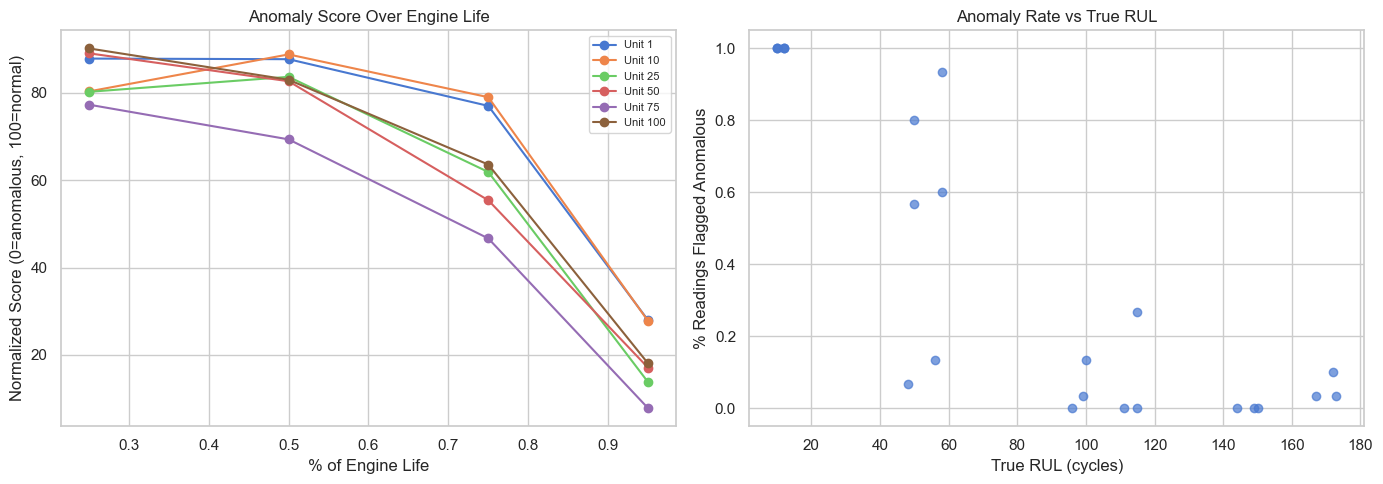

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomaly score vs % life
for unit_id in sample_units:
    unit_results = results_df[results_df["unit_id"] == unit_id]
    axes[0].plot(unit_results["pct_life"], unit_results["normalized_score"],
                 marker="o", label=f"Unit {unit_id}")
axes[0].set_xlabel("% of Engine Life")
axes[0].set_ylabel("Normalized Score (0=anomalous, 100=normal)")
axes[0].set_title("Anomaly Score Over Engine Life")
axes[0].legend(fontsize=8)

# % anomalous readings vs true RUL
axes[1].scatter(results_df["true_rul"], results_df["pct_anomalous"], alpha=0.7)
axes[1].set_xlabel("True RUL (cycles)")
axes[1].set_ylabel("% Readings Flagged Anomalous")
axes[1].set_title("Anomaly Rate vs True RUL")

plt.tight_layout()
plt.show()

### 1.2 Feature Importance

Which sensors contribute most to anomaly detection near end-of-life?

In [5]:
# Score a late-life window for unit 1
unit1 = df[df["unit_id"] == 1].sort_values("cycle")
late_window = unit1.tail(30)
late_result = score_window(late_window)

print(f"Unit 1 near failure — anomaly score: {late_result['anomaly_score']:.4f}")
print(f"Normalized: {late_result['normalized_score']:.1f}/100")
print(f"\nTop contributing sensors:")
for s in late_result["top_contributing_sensors"]:
    print(f"  {s['sensor']}: {s['contribution']:.6f}")

Unit 1 near failure — anomaly score: -0.1750
Normalized: 13.5/100

Top contributing sensors:
  sensor_20: 0.001825
  sensor_14: 0.001167
  sensor_17: 0.001084
  sensor_2: 0.000876
  sensor_4: 0.000371


### 1.3 Fleet-Wide Anomaly Score Distribution

Score all 100 units at end-of-life vs early life to confirm separation.

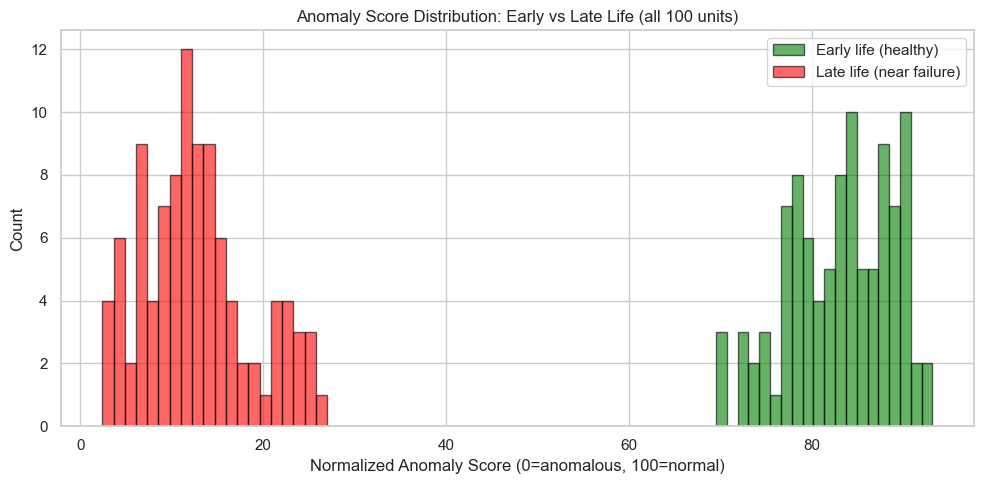

Early life mean score: 83.1 (should be high/normal)
Late life mean score: 12.7 (should be lower/anomalous)


In [6]:
early_scores = []
late_scores = []

for unit_id in df["unit_id"].unique():
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    # Early life (first 30 cycles)
    early = unit_data.head(30)
    if len(early) >= 15:
        r = score_window(early)
        early_scores.append(r["normalized_score"])
    
    # Late life (last 30 cycles)
    late = unit_data.tail(30)
    if len(late) >= 15:
        r = score_window(late)
        late_scores.append(r["normalized_score"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(early_scores, bins=20, alpha=0.6, label="Early life (healthy)", color="green", edgecolor="black")
ax.hist(late_scores, bins=20, alpha=0.6, label="Late life (near failure)", color="red", edgecolor="black")
ax.set_xlabel("Normalized Anomaly Score (0=anomalous, 100=normal)")
ax.set_ylabel("Count")
ax.set_title("Anomaly Score Distribution: Early vs Late Life (all 100 units)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Early life mean score: {np.mean(early_scores):.1f} (should be high/normal)")
print(f"Late life mean score: {np.mean(late_scores):.1f} (should be lower/anomalous)")

## 2. Build Degradation Profiles & Validate RUL

In [7]:
profiles = build_degradation_profiles()

print(f"{'Sensor':<12} {'Mean Slope':>12} {'Std Slope':>12} {'Knee Frac':>10} {'Threshold':>12}")
print("-" * 60)
for sensor in KEY_SENSORS:
    p = profiles[sensor]
    print(f"{sensor:<12} {p['mean_slope']:>+12.6f} {p['std_slope']:>12.6f} {p['mean_knee_fraction']:>10.2f} {p['mean_threshold']:>12.2f}")

Sensor         Mean Slope    Std Slope  Knee Frac    Threshold
------------------------------------------------------------
sensor_2        +0.015266     0.007242       0.67       643.60
sensor_3        +0.181496     0.093819       0.65      1601.44
sensor_4        +0.287493     0.095110       0.67      1427.39
sensor_7        -0.026749     0.010790       0.66       551.63
sensor_11       +0.008836     0.002836       0.68        48.10
sensor_12       -0.022562     0.008259       0.66       519.93
sensor_15       +0.001150     0.000461       0.65         8.52


### 2.1 RUL Estimation vs True RUL

For each unit, estimate RUL at various points in its life and compare to ground truth.

In [8]:
rul_results = []

for unit_id in df["unit_id"].unique():
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    # Estimate at 50%, 75%, 90% of life
    for pct in [0.50, 0.75, 0.90]:
        cutoff_cycle = int(max_cycle * pct)
        history = unit_data[unit_data["cycle"] <= cutoff_cycle]
        if len(history) < 20:
            continue
        
        result = estimate_rul(history)
        true_rul = max_cycle - cutoff_cycle
        
        rul_results.append({
            "unit_id": unit_id,
            "pct_life": pct,
            "true_rul": true_rul,
            "estimated_rul": result["estimated_rul"],
            "ci_lower": result["confidence_interval"][0],
            "ci_upper": result["confidence_interval"][1],
            "stage": result["degradation_stage"],
            "n_degrading_sensors": len(result["key_degrading_sensors"]),
        })

rul_df = pd.DataFrame(rul_results)
print(f"Total RUL evaluations: {len(rul_df)}")
rul_df.head(10)

Total RUL evaluations: 300


,unit_id,pct_life,true_rul,estimated_rul,ci_lower,ci_upper,stage,n_degrading_sensors
0,1,0.50,96,62,43,78,degrading,7
1,1,0.75,48,49,33,63,degrading,6
2,1,0.90,20,24,16,31,critical,7
3,2,0.50,144,56,28,114,healthy,0
4,2,0.75,72,57,38,72,degrading,6
5,2,0.90,29,27,17,32,critical,7
6,3,0.50,90,110,55,195,healthy,0
7,3,0.75,45,56,38,73,degrading,7
8,3,0.90,18,34,24,46,degrading,7
9,4,0.50,95,63,42,82,degrading,7


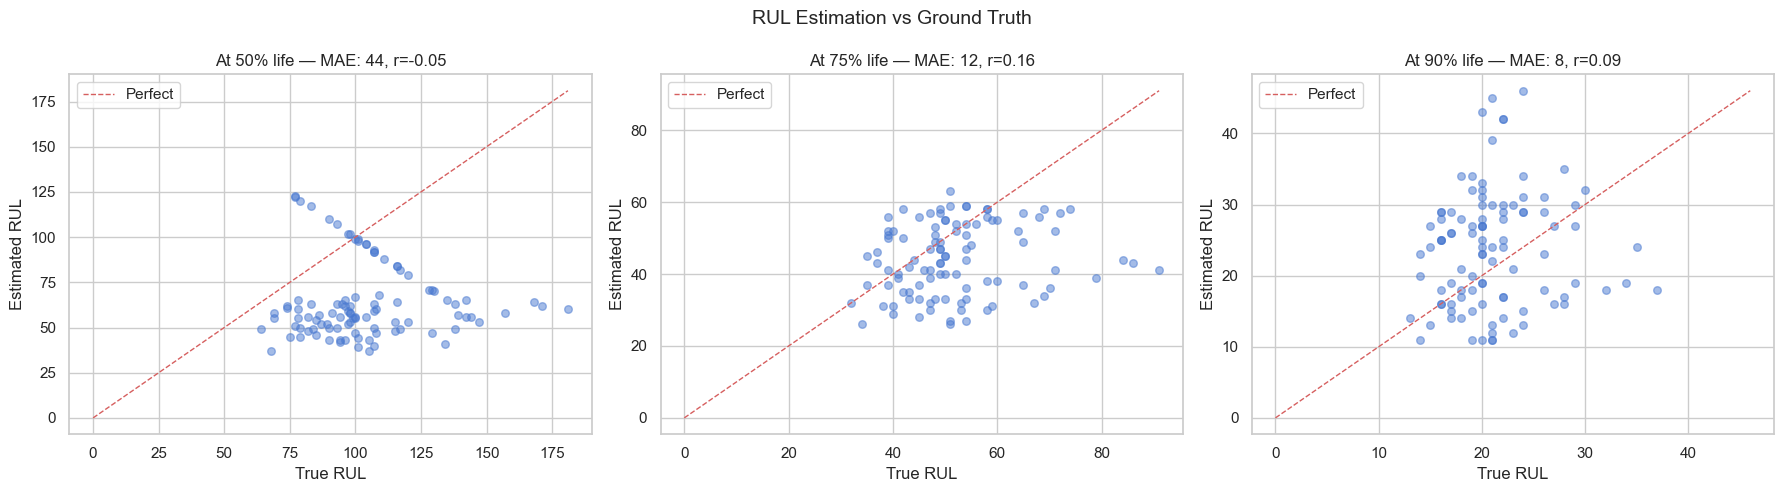

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, pct in enumerate([0.50, 0.75, 0.90]):
    ax = axes[i]
    subset = rul_df[rul_df["pct_life"] == pct]
    
    ax.scatter(subset["true_rul"], subset["estimated_rul"], alpha=0.5, s=30)
    
    # Perfect prediction line
    max_val = max(subset["true_rul"].max(), subset["estimated_rul"].max())
    ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Perfect")
    
    # Error metrics
    mae = (subset["estimated_rul"] - subset["true_rul"]).abs().mean()
    corr = subset["true_rul"].corr(subset["estimated_rul"])
    
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Estimated RUL")
    ax.set_title(f"At {int(pct*100)}% life — MAE: {mae:.0f}, r={corr:.2f}")
    ax.legend()

plt.suptitle("RUL Estimation vs Ground Truth", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Confidence interval coverage: what % of true RUL values fall within the CI?
rul_df["ci_covers"] = (rul_df["true_rul"] >= rul_df["ci_lower"]) & (rul_df["true_rul"] <= rul_df["ci_upper"])

print("Confidence interval coverage (target: ~90%):")
for pct in [0.50, 0.75, 0.90]:
    subset = rul_df[rul_df["pct_life"] == pct]
    coverage = subset["ci_covers"].mean() * 100
    mae = (subset["estimated_rul"] - subset["true_rul"]).abs().mean()
    print(f"  At {int(pct*100)}% life: coverage={coverage:.0f}%, MAE={mae:.0f} cycles")

# Degradation stage accuracy
print("\nDegradation stage distribution:")
print(rul_df.groupby(["pct_life", "stage"]).size().unstack(fill_value=0))

Confidence interval coverage (target: ~90%):
  At 50% life: coverage=33%, MAE=44 cycles
  At 75% life: coverage=68%, MAE=12 cycles
  At 90% life: coverage=60%, MAE=8 cycles

Degradation stage distribution:
stage     critical  degrading  healthy
pct_life                              
0.50             0         73       27
0.75             6         94        0
0.90            78         22        0


## 3. Sensor Trend Analysis Validation

In [11]:
# Analyze trends for a few sample units at different life stages
sample_units = [1, 25, 50, 75]

for unit_id in sample_units:
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    print(f"\n{'='*60}")
    print(f"Unit {unit_id} (lifetime: {max_cycle} cycles)")
    
    for pct in [0.40, 0.80]:
        cutoff = int(max_cycle * pct)
        history = unit_data[unit_data["cycle"] <= cutoff]
        trends = analyze_trends(history)
        
        print(f"\n  At {int(pct*100)}% life (cycle {cutoff}):")
        print(f"    Trend summary: {trends['trend_summary']}")
        print(f"    Change points detected: {len(trends['change_points'])}")
        
        if trends['cross_sensor_divergence']:
            top_div = max(trends['cross_sensor_divergence'].items(), key=lambda x: x[1])
            print(f"    Max divergence: {top_div[0]} = {top_div[1]:.4f}")
        
        # Show rolling features for top 3 sensors by slope magnitude
        sorted_sensors = sorted(
            trends['rolling_features'].items(),
            key=lambda x: abs(x[1]['slope']),
            reverse=True
        )[:3]
        for sensor, feat in sorted_sensors:
            print(f"    {sensor}: slope={feat['slope']:.6f}, rate={feat['rate_of_change']:.6f}")


Unit 1 (lifetime: 192 cycles)

  At 40% life (cycle 76):
    Trend summary: gradual_degradation
    Change points detected: 0
    Max divergence: sensor_4/sensor_15 = 0.5862
    sensor_3: slope=-0.137947, rate=-0.000087
    sensor_4: slope=-0.085474, rate=-0.000061
    sensor_7: slope=-0.010594, rate=-0.000019

  At 80% life (cycle 153):
    Trend summary: gradual_degradation
    Change points detected: 17
    Max divergence: sensor_7/sensor_12 = 0.2263
    sensor_4: slope=0.423962, rate=0.000301
    sensor_3: slope=0.293135, rate=0.000184
    sensor_12: slope=-0.040564, rate=-0.000078

Unit 25 (lifetime: 230 cycles)

  At 40% life (cycle 92):
    Trend summary: stable
    Change points detected: 1
    Max divergence: sensor_11/sensor_12 = 0.3724
    sensor_4: slope=0.186632, rate=0.000133
    sensor_3: slope=0.056714, rate=0.000036
    sensor_12: slope=-0.021662, rate=-0.000042

  At 80% life (cycle 184):
    Trend summary: gradual_degradation
    Change points detected: 13
    Max d

In [12]:
# Fleet-wide trend classification accuracy
# At 40% life most units should be stable; at 90% most should be degrading/accelerating
trend_results = []

for unit_id in df["unit_id"].unique():
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    for pct in [0.40, 0.70, 0.90]:
        cutoff = int(max_cycle * pct)
        history = unit_data[unit_data["cycle"] <= cutoff]
        if len(history) < 20:
            continue
        trends = analyze_trends(history)
        trend_results.append({
            "unit_id": unit_id,
            "pct_life": pct,
            "trend_summary": trends["trend_summary"],
            "n_change_points": len(trends["change_points"]),
        })

trend_df = pd.DataFrame(trend_results)
print("Trend classification distribution by life stage:")
print(trend_df.groupby(["pct_life", "trend_summary"]).size().unstack(fill_value=0))
print("\nChange points detected (mean per unit):")
print(trend_df.groupby("pct_life")["n_change_points"].mean())

Trend classification distribution by life stage:
trend_summary  accelerating  gradual_degradation  stable
pct_life                                                
0.4                       1                   67      32
0.7                       2                   91       7
0.9                       4                   96       0

Change points detected (mean per unit):
pct_life
0.4     0.57
0.7     9.77
0.9    22.52
Name: n_change_points, dtype: float64


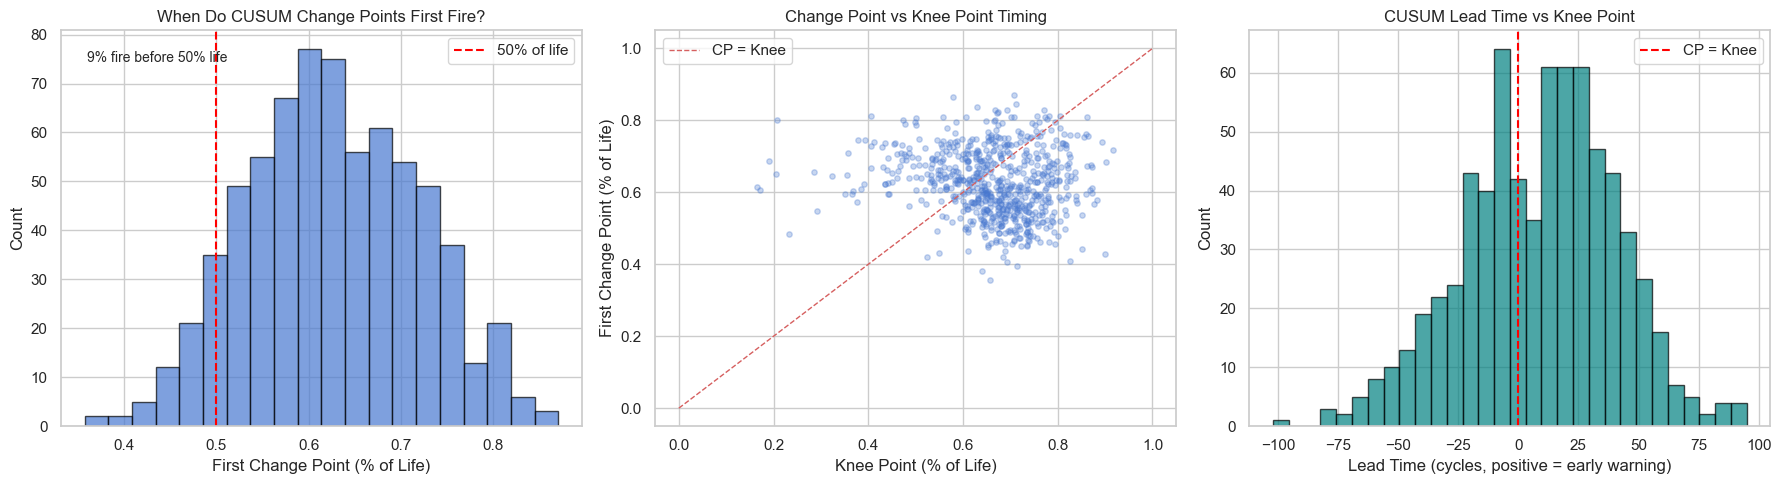


Change-point early warning by sensor:
Sensor       Median CP% Median Knee%  CP Before Knee%
------------------------------------------------------
sensor_2           0.68         0.69              43%
sensor_3           0.72         0.67              35%
sensor_4           0.58         0.68              75%
sensor_7           0.60         0.65              64%
sensor_11          0.55         0.69              86%
sensor_12          0.58         0.67              70%
sensor_15          0.65         0.65              46%


In [13]:
from src.models.rul_estimator import _detect_knee_point

cp_timing = []

for unit_id in df["unit_id"].unique():
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    # Run trend analysis on full life to get all change points
    trends = analyze_trends(unit_data)
    
    for sensor in KEY_SENSORS:
        # Find first CUSUM change point for this sensor
        sensor_cps = [cp for cp in trends["change_points"] if cp["sensor"] == sensor]
        
        # Find actual knee point
        values = unit_data[sensor].values
        smoothed = pd.Series(values).rolling(window=10, min_periods=1).mean().values
        knee_idx = _detect_knee_point(smoothed)
        
        if sensor_cps:
            first_cp = sensor_cps[0]["cycle_index"]
            cp_timing.append({
                "unit_id": unit_id,
                "sensor": sensor,
                "max_cycle": max_cycle,
                "first_cp_cycle": first_cp,
                "first_cp_pct_life": first_cp / max_cycle,
                "knee_cycle": knee_idx,
                "knee_pct_life": knee_idx / max_cycle,
                "cp_lead": knee_idx - first_cp,  # positive = CP fires before knee
            })

cp_df = pd.DataFrame(cp_timing)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of first change-point as % of life
axes[0].hist(cp_df["first_cp_pct_life"], bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(0.5, color="red", linestyle="--", label="50% of life")
axes[0].set_xlabel("First Change Point (% of Life)")
axes[0].set_ylabel("Count")
axes[0].set_title("When Do CUSUM Change Points First Fire?")
axes[0].legend()

early_pct = (cp_df["first_cp_pct_life"] < 0.5).mean() * 100
axes[0].annotate(f"{early_pct:.0f}% fire before 50% life",
                 xy=(0.05, 0.92), xycoords="axes fraction", fontsize=10)

# 2. Change point vs knee point timing
axes[1].scatter(cp_df["knee_pct_life"], cp_df["first_cp_pct_life"], alpha=0.3, s=15)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1, label="CP = Knee")
axes[1].set_xlabel("Knee Point (% of Life)")
axes[1].set_ylabel("First Change Point (% of Life)")
axes[1].set_title("Change Point vs Knee Point Timing")
axes[1].legend()

# 3. Lead time distribution (positive = CP fires before knee = early warning)
axes[2].hist(cp_df["cp_lead"], bins=30, edgecolor="black", alpha=0.7, color="teal")
axes[2].axvline(0, color="red", linestyle="--", label="CP = Knee")
axes[2].set_xlabel("Lead Time (cycles, positive = early warning)")
axes[2].set_ylabel("Count")
axes[2].set_title("CUSUM Lead Time vs Knee Point")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats per sensor
print("\nChange-point early warning by sensor:")
print(f"{'Sensor':<12} {'Median CP%':>10} {'Median Knee%':>12} {'CP Before Knee%':>16}")
print("-" * 54)
for sensor in KEY_SENSORS:
    s = cp_df[cp_df["sensor"] == sensor]
    if len(s) == 0:
        continue
    print(f"{sensor:<12} {s['first_cp_pct_life'].median():>10.2f} "
          f"{s['knee_pct_life'].median():>12.2f} "
          f"{(s['cp_lead'] > 0).mean() * 100:>15.0f}%")

### 3.1 Change-Point Timing vs Actual Degradation Onset

Do CUSUM change points fire as early warnings — before 50% of engine life?
Compare the first detected change-point cycle to the actual knee point (where
the sensor value departs from its healthy baseline).

## 4. Health Index Composite Validation

In [14]:
# Compute health index for sample units across their full life
health_results = []

for unit_id in [1, 10, 25, 50, 75, 100]:
    unit_data = df[df["unit_id"] == unit_id].sort_values("cycle")
    max_cycle = unit_data["cycle"].max()
    
    for pct in [0.20, 0.40, 0.60, 0.80, 0.95]:
        cutoff = int(max_cycle * pct)
        history = unit_data[unit_data["cycle"] <= cutoff]
        window = history.tail(30)
        
        if len(window) < 10 or len(history) < 20:
            continue
        
        anomaly_result = score_window(window)
        rul_result = estimate_rul(history)
        hi = compute_health_index(anomaly_result, rul_result)
        
        health_results.append({
            "unit_id": unit_id,
            "pct_life": pct,
            "true_rul": max_cycle - cutoff,
            "health_index": hi,
            "label": health_label(hi),
            "anomaly_normalized": anomaly_result["normalized_score"],
            "estimated_rul": rul_result["estimated_rul"],
        })

hi_df = pd.DataFrame(health_results)
print(hi_df.to_string(index=False))

 unit_id  pct_life  true_rul  health_index        label  anomaly_normalized  estimated_rul
       1      0.20       154     83.196099      healthy           86.633464            161
       1      0.40       116     72.471037    degrading           88.464025            123
       1      0.60        77     52.453306    degrading           85.907135             60
       1      0.80        39     40.548996     critical           69.714199             42
       1      0.95        10     14.793035 near_failure           27.937362             12
      10      0.20       178     79.354796    degrading           81.552820            155
      10      0.40       134     68.954277    degrading           88.717352            111
      10      0.60        89     56.712559    degrading           92.032655             66
      10      0.80        45     41.001707     critical           68.584669             45
      10      0.95        12     16.834207 near_failure           27.763910             19

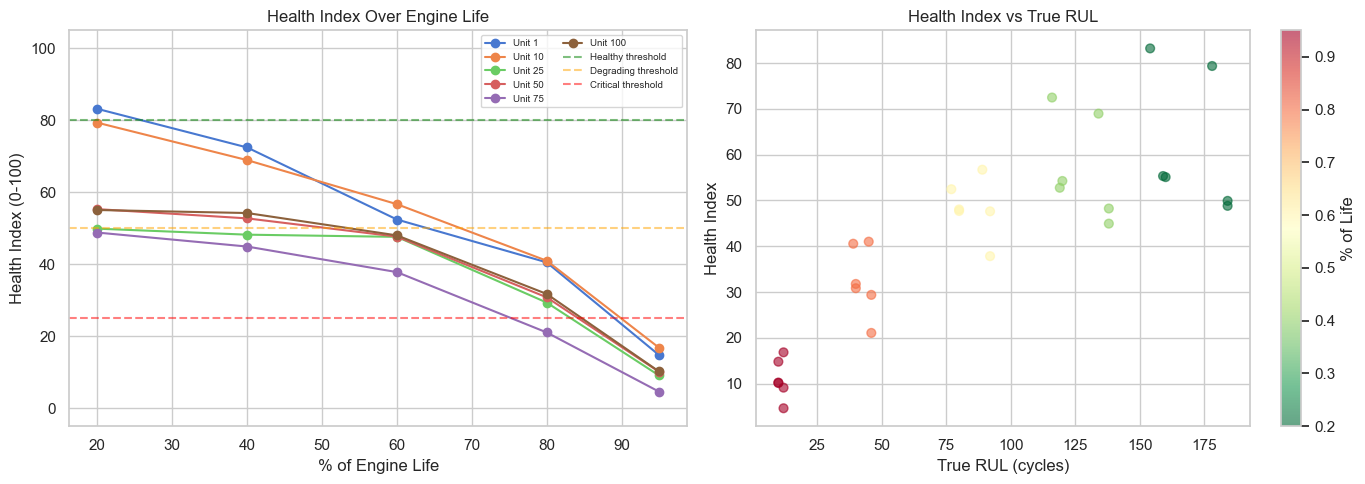

Health Index vs True RUL correlation: 0.828


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Health index vs % life
for unit_id in hi_df["unit_id"].unique():
    subset = hi_df[hi_df["unit_id"] == unit_id]
    axes[0].plot(subset["pct_life"] * 100, subset["health_index"],
                 marker="o", label=f"Unit {unit_id}")

axes[0].axhline(80, color="green", linestyle="--", alpha=0.5, label="Healthy threshold")
axes[0].axhline(50, color="orange", linestyle="--", alpha=0.5, label="Degrading threshold")
axes[0].axhline(25, color="red", linestyle="--", alpha=0.5, label="Critical threshold")
axes[0].set_xlabel("% of Engine Life")
axes[0].set_ylabel("Health Index (0-100)")
axes[0].set_title("Health Index Over Engine Life")
axes[0].legend(fontsize=7, ncol=2)
axes[0].set_ylim(-5, 105)

# Health index vs true RUL
axes[1].scatter(hi_df["true_rul"], hi_df["health_index"], alpha=0.6,
                c=hi_df["pct_life"], cmap="RdYlGn_r", s=40)
axes[1].set_xlabel("True RUL (cycles)")
axes[1].set_ylabel("Health Index")
axes[1].set_title("Health Index vs True RUL")
cb = plt.colorbar(axes[1].collections[0], ax=axes[1])
cb.set_label("% of Life")

plt.tight_layout()
plt.show()

# Correlation
print(f"Health Index vs True RUL correlation: {hi_df['true_rul'].corr(hi_df['health_index']):.3f}")

## 5. Summary Metrics

In [16]:
print("=" * 60)
print("DAY 2 MODEL VALIDATION SUMMARY")
print("=" * 60)

# Anomaly detection
print("\n1. ISOLATION FOREST")
print(f"   Training samples: {train_meta['n_healthy_samples']}")
print(f"   Features: {train_meta['n_features']} informative sensors")
print(f"   Early-life mean score: {np.mean(early_scores):.1f}/100")
print(f"   Late-life mean score: {np.mean(late_scores):.1f}/100")
print(f"   Score separation: {np.mean(early_scores) - np.mean(late_scores):.1f} points")

# RUL estimation
print("\n2. PIECEWISE LINEAR RUL")
for pct in [0.50, 0.75, 0.90]:
    subset = rul_df[rul_df["pct_life"] == pct]
    mae = (subset["estimated_rul"] - subset["true_rul"]).abs().mean()
    corr = subset["true_rul"].corr(subset["estimated_rul"])
    coverage = subset["ci_covers"].mean() * 100
    print(f"   At {int(pct*100)}% life: MAE={mae:.0f} cycles, r={corr:.2f}, CI coverage={coverage:.0f}%")

# Trend analysis
print("\n3. TREND ANALYSIS")
for pct in [0.40, 0.70, 0.90]:
    subset = trend_df[trend_df["pct_life"] == pct]
    dist = subset["trend_summary"].value_counts(normalize=True) * 100
    print(f"   At {int(pct*100)}% life: " + ", ".join(f"{k}={v:.0f}%" for k, v in dist.items()))

# Health index
print("\n4. HEALTH INDEX")
print(f"   Correlation with true RUL: {hi_df['true_rul'].corr(hi_df['health_index']):.3f}")
print(f"   Label distribution:")
for label in ["healthy", "degrading", "critical", "near_failure"]:
    count = (hi_df["label"] == label).sum()
    if count > 0:
        print(f"     {label}: {count} ({count/len(hi_df)*100:.0f}%)")

DAY 2 MODEL VALIDATION SUMMARY

1. ISOLATION FOREST
   Training samples: 6144
   Features: 14 informative sensors
   Early-life mean score: 83.1/100
   Late-life mean score: 12.7/100
   Score separation: 70.4 points

2. PIECEWISE LINEAR RUL
   At 50% life: MAE=44 cycles, r=-0.05, CI coverage=33%
   At 75% life: MAE=12 cycles, r=0.16, CI coverage=68%
   At 90% life: MAE=8 cycles, r=0.09, CI coverage=60%

3. TREND ANALYSIS
   At 40% life: gradual_degradation=67%, stable=32%, accelerating=1%
   At 70% life: gradual_degradation=91%, stable=7%, accelerating=2%
   At 90% life: gradual_degradation=96%, accelerating=4%

4. HEALTH INDEX
   Correlation with true RUL: 0.828
   Label distribution:
     healthy: 1 (3%)
     degrading: 9 (30%)
     critical: 13 (43%)
     near_failure: 7 (23%)
